In [1]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/processed/clean_data.csv")

df.head()

,user_id,gender,age,state_tier,occupation_class,salary_bracket,total_income_inr,is_smoker,family_members,medical_plan,annual_expenditure_inr
0,1,Male,19,Tier-2,Low-Risk,Tier-1,203736,0,5,Medium,89149
1,2,Female,20,Tier-1,Low-Risk,Tier-2,527824,0,6,Medium,115346
2,3,Male,46,Tier-2,High-Risk,Tier-1,233707,0,3,High,128494
3,4,Male,66,Tier-1,Low-Risk,Tier-1,330331,0,1,Medium,126971
4,5,Male,42,Tier-1,Low-Risk,Tier-2,879201,0,6,Medium,142701


In [3]:
df.shape

(980, 11)

In [5]:
# Entering into EDA:

# Does smoking affect the medical plan?

# 1st predictor - is_smoker

pd.crosstab(
    df["is_smoker"],
    df["medical_plan"]
)

medical_plan,High,Low,Medium
is_smoker,,,
0,245,144,382
1,173,11,25


In [6]:
pd.crosstab(
    df["is_smoker"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
is_smoker,,,
0,31.776913,18.677043,49.546044
1,82.775120,5.263158,11.961722


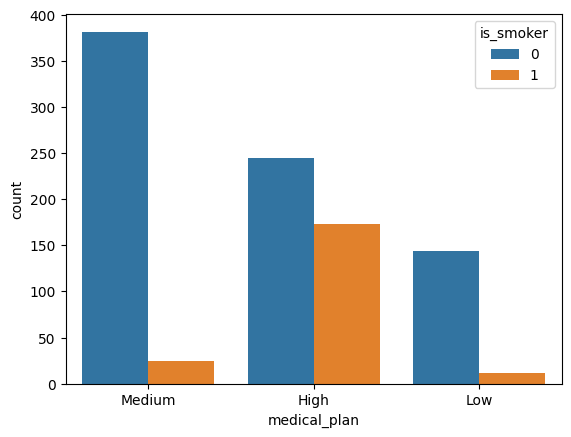

In [7]:
sns.countplot(data=df,x = "medical_plan", hue="is_smoker")
plt.show()

# People who are smokers tend to to choose high medical plan as comapred to non- smokers.

In [8]:
# Other predictors can be explored in a similar way.

# 2nd predictor - age

df.groupby("medical_plan")["age"].mean() 

medical_plan
High      53.796651
Low       34.167742
Medium    41.965602
Name: age, dtype: float64

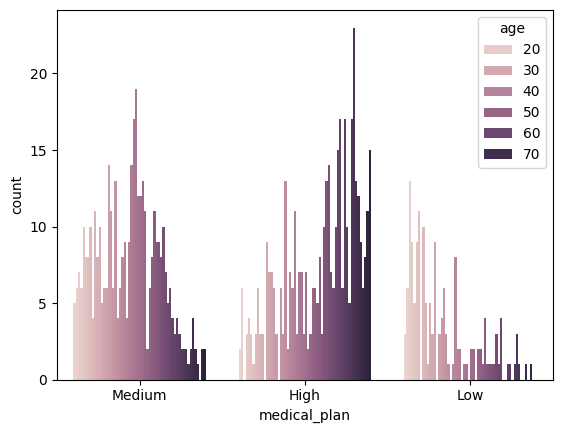

In [9]:
sns.countplot(data=df,x = "medical_plan", hue="age")
plt.show()

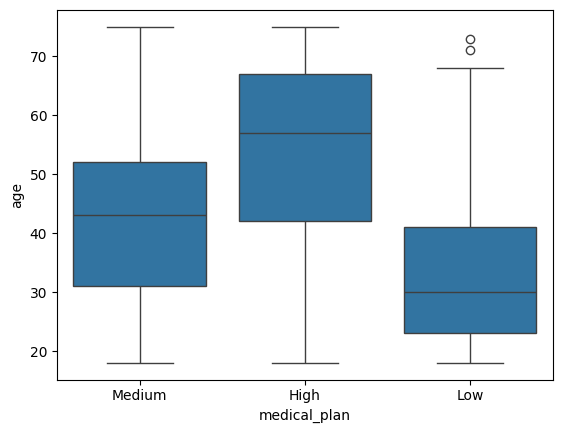

In [10]:
sns.boxplot(
    data=df,
    x="medical_plan",
    y="age"
)

plt.show()

In [11]:
df.groupby("medical_plan")["age"].median() 

medical_plan
High      57.0
Low       30.0
Medium    43.0
Name: age, dtype: float64

In [12]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,75],
    labels=[
        "18-30",
        "31-45",
        "46-60",
        "61-75"
    ]
)

In [13]:
pd.crosstab(
    df["age_group"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
age_group,,,
18-30,19.431280,36.492891,44.075829
31-45,32.000000,14.909091,53.090909
46-60,40.077821,9.727626,50.194553
61-75,81.057269,3.964758,14.977974


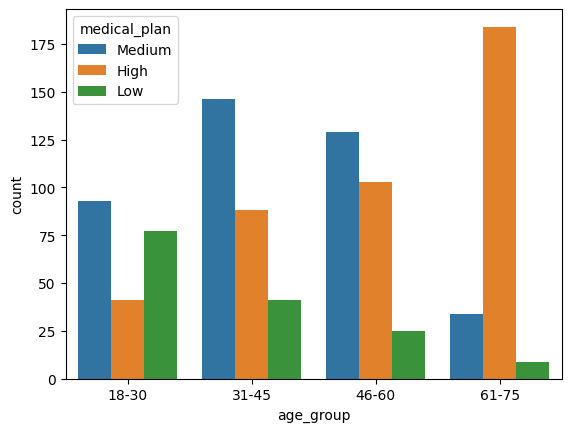

In [14]:
sns.countplot(
    data=df,
    x="age_group",
    hue="medical_plan"
)

plt.show()

In [15]:
# FYI 2. Features which are numerical in nature often needs plots like:
# histogram
# boxplot
# distribution plot
# violinplot
# age buckets + percentage table

In [16]:
# FYI 3. Features which are categorical in nature often needs plots like:
# countplot
# crosstab
# percentage table

In [17]:
# 3rd predictor - annual_expenditure_inr

df.groupby("medical_plan")["annual_expenditure_inr"].mean()

medical_plan
High      187141.066986
Low        69296.787097
Medium    105658.191646
Name: annual_expenditure_inr, dtype: float64

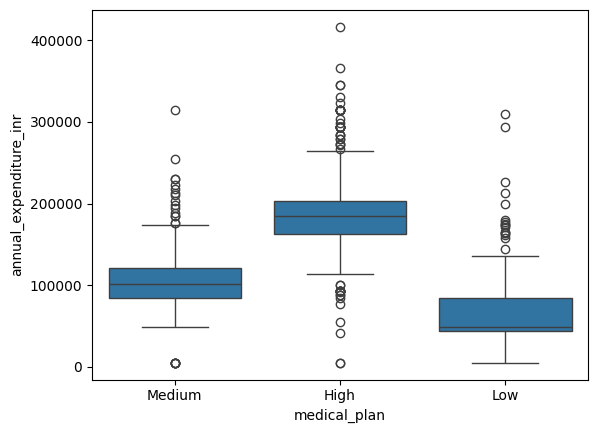

In [18]:
sns.boxplot(
    data=df,
    x="medical_plan",
    y="annual_expenditure_inr"
)

plt.show()

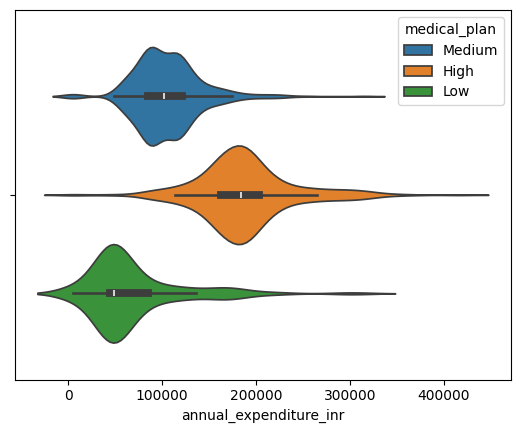

In [19]:
sns.violinplot(
    data=df,
    x="annual_expenditure_inr",
    hue="medical_plan"
)

plt.show()

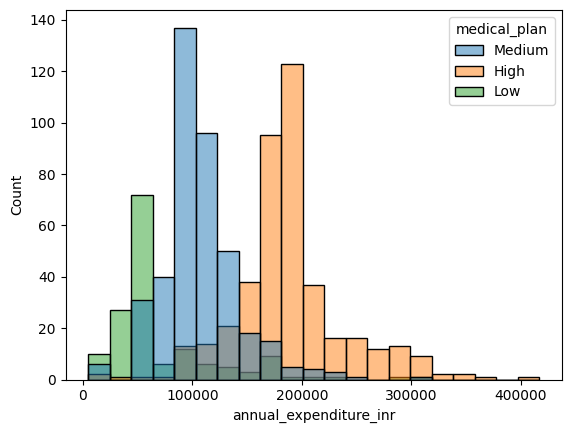

In [20]:
sns.histplot(
    data=df,
    x="annual_expenditure_inr",
    hue="medical_plan"
)

plt.show()

In [21]:
df["annual_expenditure_inr_group"] = pd.cut(
    df["annual_expenditure_inr"],
    bins=[0,50000,100000,150000,200000],
    labels=[
        "0-50k",
        "50k-1L",
        "1L-1.5L",
        "1.5L-2L"
    ]
)
    

In [22]:
pd.crosstab(
    df["annual_expenditure_inr_group"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
annual_expenditure_inr_group,,,
0-50k,3.157895,89.473684,7.368421
50k-1L,5.263158,16.194332,78.542510
1L-1.5L,22.649573,5.982906,71.367521
1.5L-2L,85.053381,4.270463,10.676157


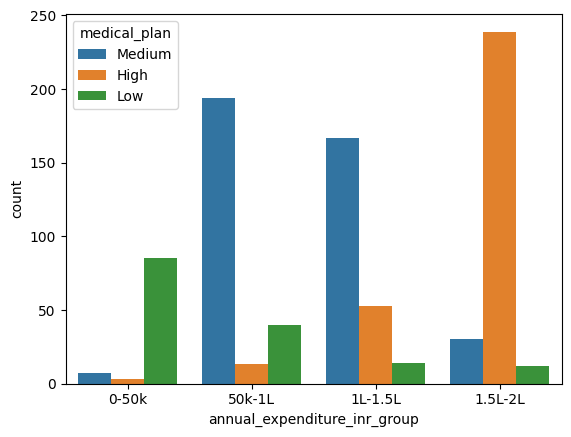

In [23]:
sns.countplot(
    data=df,
    x="annual_expenditure_inr_group",
    hue="medical_plan"
)

plt.show()

In [ ]:
# So far our conclusion is:

# 1. is_smoker -> 82.7% High (Strong predictor)
# 2. age -> Older people → more High plans (Strong predictor)
# 3. annual_expenditure_inr -> 1.5L-2L -> 85% High plan (Strong predictor)

In [25]:
# 4th predictor - total_income_inr

df["total_income_inr"].describe()

count    9.800000e+02
mean     9.241866e+05
std      8.652394e+05
min      1.519340e+05
25%      4.117075e+05
50%      7.894210e+05
75%      1.124310e+06
max      4.997509e+06
Name: total_income_inr, dtype: float64

# Above Code Description:

- count    9.800000e+02 -> 980 non-missing values
- mean     9.241866e+05 -> average total income is around 9.24 lakhs
- std      8.652394e+05 -> there is a high variability in total income among the individuals in the dataset, bascially tells about the spread of the total income values.
- here std almost equals mean, which menas -> huge spread -> huge variability -> makes sus about outliers and income skewnes
- min      1.519340e+05 -> minimum total income is around 1.5 lakhs
- 25%      4.117075e+05 -> 25% people earn below ₹4.1 lakh
- 50%/median      7.894210e+05 -> 50% people earn below ₹7.89 lakh and 50% people earn above ₹7.89 lakh
- here mean > median, which means the distribution is right skewed, which means there are some high income outliers in the dataset which is pulling the mean towards right.

- 75%      1.124310e+06 -> 75% people earn below ₹11.24 lakh
- max      4.997509e+06 -> Highest income ≈ ₹50 lakh
- here 75% to max is a huge jump, which again confirms the presence of high income outliers in the dataset.

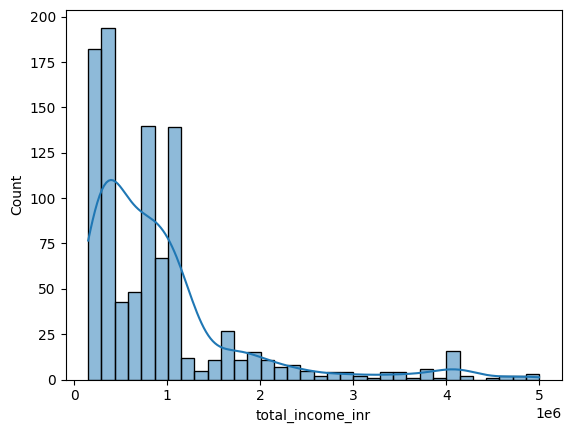

In [27]:
sns.histplot(
    data=df,
    x="total_income_inr",
    kde=True
)

plt.show()

In [28]:
# mean > median -> right skewed distribution, presence of high income outliers in the dataset.

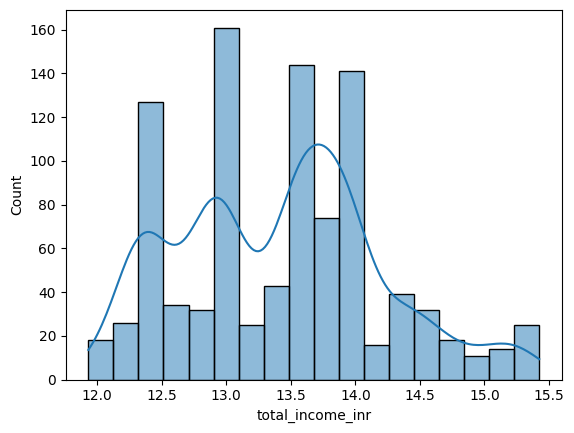

In [29]:
sns.histplot(
    np.log1p(df["total_income_inr"]),
    kde=True
)

plt.show()

In [32]:
df["income_group"] = pd.cut(
    df["total_income_inr"],
    bins=[0, 500000, 1000000, 2000000, 5000000],
    labels=[
        "0-5L",
        "5L-10L",
        "10L-20L",
        "20L+"
    ]
)

In [33]:
pd.crosstab(
    df["income_group"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
income_group,,,
0-5L,31.435644,27.475248,41.089109
5L-10L,47.211896,7.063197,45.724907
10L-20L,53.393665,7.239819,39.366516
20L+,53.488372,10.465116,36.046512


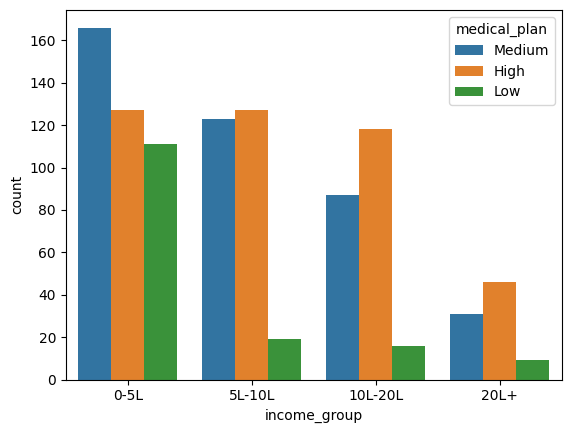

In [34]:
sns.countplot(
    data=df,
    x="income_group",
    hue="medical_plan"
)

plt.show()

In [35]:
# Conclusion:
'''
As income increases, the proportion of High medical plan selections increases from 31% to 53%.

However, the increase is gradual rather than dramatic.

Inference:
Income appears to influence medical plan selection, but the relationship is weaker than the one observed with annual medical expenditure.'''

'\nAs income increases, the proportion of High medical plan selections increases from 31% to 53%.\n\nHowever, the increase is gradual rather than dramatic.\n\nInference:\nIncome appears to influence medical plan selection, but the relationship is weaker than the one observed with annual medical expenditure.'

In [36]:
# 5th predictor - occupation_class

pd.crosstab(
    df["occupation_class"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
occupation_class,,,
High-Risk,59.633028,6.422018,33.944954
Low-Risk,39.443535,17.512275,43.044190
Medium-Risk,43.076923,15.769231,41.153846


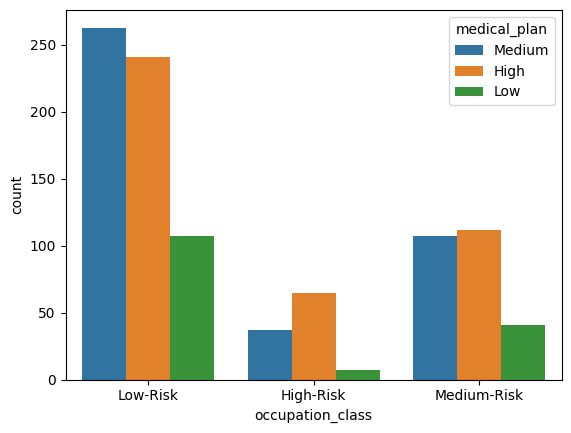

In [37]:
sns.countplot(
    data=df,
    x="occupation_class",
    hue="medical_plan"
)

plt.show()

In [38]:
# FYI 4.
# Not look for : Which bar is tallest?
# Look for : Does High-Risk occupation , have a higher percentage of High plans?
# Counts can fool us in such plots.

In [ ]:
# Conclusion:
'''
Occupation class appears to influence medical plan choice.

People in higher-risk occupations tend to select higher medical plans more frequently.

Whether this is moderate or strong should be decided from the percentage crosstab, not the countplot.
'''

In [ ]:
# EDA PHASE 2:
# Understanding relationships between predictors and multicollinearity.

In [39]:
df.select_dtypes(include="number").corr() # correlation matrix of numerical features to understand relationships and check for multicollinearity.

,user_id,age,total_income_inr,is_smoker,family_members,annual_expenditure_inr
user_id,1.000000,-0.020669,-0.166480,0.008163,0.003495,-0.124620
age,-0.020669,1.000000,0.105442,0.027601,0.063207,0.603656
total_income_inr,-0.166480,0.105442,1.000000,0.024159,0.071803,0.115009
is_smoker,0.008163,0.027601,0.024159,1.000000,0.050642,0.578128
family_members,0.003495,0.063207,0.071803,0.050642,1.000000,0.351868
annual_expenditure_inr,-0.124620,0.603656,0.115009,0.578128,0.351868,1.000000


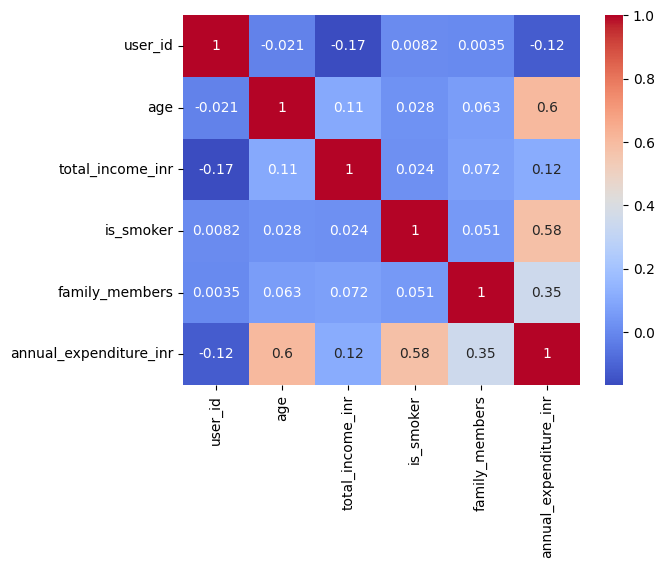

In [40]:
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [ ]:
'''
+1  -> Perfect Positive Relationship
 0  -> No Relationship
-1  -> Perfect Negative Relationship
'''

In [ ]:
"""

Correlation Analysis:

1. Age and Annual Expenditure show a moderate positive relationship (0.60), indicating that older individuals tend to spend more on healthcare.

2. Smoking status and Annual Expenditure show a moderate positive relationship (0.58), suggesting smokers generally incur higher medical expenses.

3. Family Members and Annual Expenditure have a weak-to-moderate relationship (0.35).

4. Total Income shows very weak correlation with most numerical predictors.

5. No severe multicollinearity was observed among numerical variables.
"""

In [41]:
# 6th predictor - family_members

pd.crosstab(
    df["family_members"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
family_members,,,
1,23.899371,37.735849,38.364780
2,25.000000,30.000000,45.000000
3,30.994152,18.128655,50.877193
4,50.657895,3.947368,45.394737
5,57.309942,2.923977,39.766082
6,67.065868,2.994012,29.940120


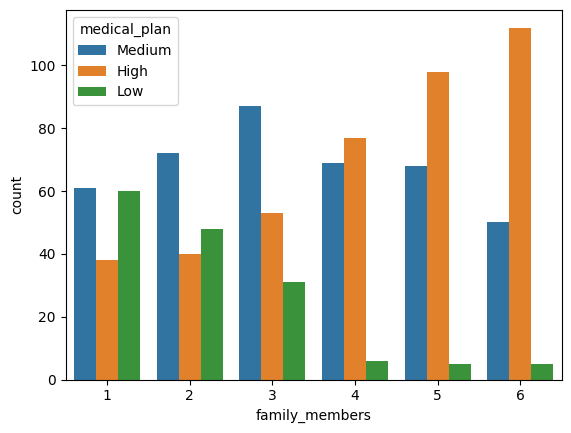

In [42]:
sns.countplot(
    data=df,
    x="family_members",
    hue="medical_plan"
)

plt.show()

In [43]:
# Weaker Predictors:

# 7th predictor - gender

pd.crosstab(
    df["gender"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
gender,,,
Female,50.206612,7.438017,42.355372
Male,35.282258,23.991935,40.725806


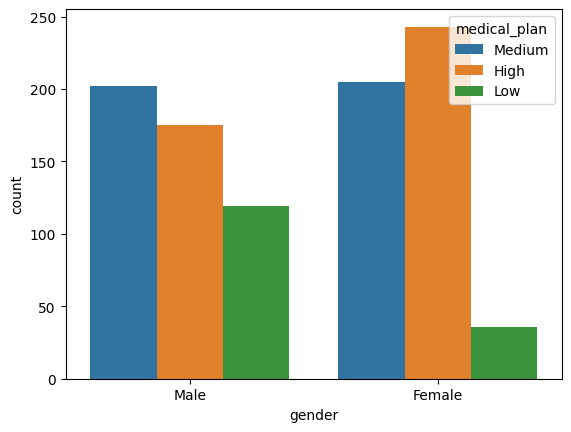

In [44]:
sns.countplot(
    data=df,
    x="gender",
    hue="medical_plan"
)
plt.show()

In [ ]:
# Conclusion:
'''
Females show a clear preference toward High medical plans,
with approximately 50% choosing High plans.

Males are more evenly distributed between Medium and High plans,
and are considerably more likely to choose Low plans.

Therefore Gender appears to have some predictive influence on Medical Plan selection.
'''

In [45]:
# Weaker Predictors:

# 8th predictor - state_tier

pd.crosstab(
    df["state_tier"],
    df["medical_plan"],
    normalize="index"
) * 100

medical_plan,High,Low,Medium
state_tier,,,
Tier-1,50.352941,2.823529,46.823529
Tier-2,41.401274,17.834395,40.764331
Tier-3,30.705394,36.099585,33.195021


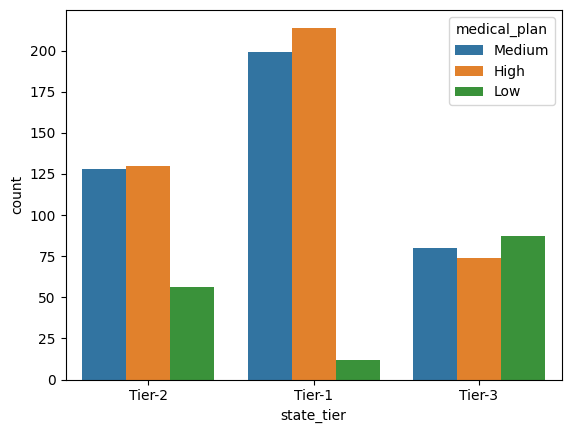

In [46]:
sns.countplot(
    data=df,
    x="state_tier",
    hue="medical_plan"
)

plt.show()

In [ ]:
# How we compare the predictive power of different predictors?
'''
Gender:

Female High = 50%
Male High   = 35%

Difference ≈ 15%

where as,

State Tier:

Tier-1 High = 50%
Tier-3 High = 31%

Difference ≈ 20%
'''
# Therefore, state tier > gender

In [ ]:
# EDA RECAP:
'''
| Feature        | Observation                              | Strength        |
| -------------- | ---------------------------------------- | --------------- |
| Smoking        | Smokers choose High plans                | Strong          |
| Age            | Older people choose High plans           | Strong          |
| Expenditure    | Higher expenditure → High plans          | Strong          |
| Family Members | Larger families → High plans             | Moderate-Strong |
| State Tier     | Tier-1 prefers High plans                | Moderate        |
| Occupation     | High-risk jobs choose High plans         | Moderate        |
| Income         | Higher income slightly favors High plans | Moderate        |
| Gender         | Females prefer High plans more           | Weak-Moderate   |
'''


In [ ]:
# Upcoming Procedure:

# Feature Engineering
# Encoding
# Train-Test Split
# First Model

# Exploratory Data Analysis (EDA) Summary

## Objective

The objective of this phase was to understand the distribution of the target variable (`medical_plan`) and identify which features have the strongest influence on medical plan selection.

---

## Target Variable Analysis

The target variable consists of three classes:

| Medical Plan | Percentage |
| ------------ | ---------- |
| High         | ~42.7%     |
| Medium       | ~41.5%     |
| Low          | ~15.8%     |

### Observation

The dataset is moderately imbalanced, with the **Low** plan category being underrepresented compared to **High** and **Medium** plans.

---

## Key Findings

### 1. Smoking Status (Strong Predictor)

* Smokers overwhelmingly prefer **High** medical plans.
* Non-smokers are distributed more evenly across Medium and High plans.
* Smoking shows a strong relationship with medical plan selection.

**Conclusion:** Smoking is one of the strongest predictors of medical plan choice.

---

### 2. Age (Strong Predictor)

* Older individuals tend to select **High** medical plans.
* Younger individuals are more likely to choose **Medium** or **Low** plans.
* The preference for High plans increases gradually with age.

**Conclusion:** Age has a significant influence on medical plan selection.

---

### 3. Annual Medical Expenditure (Strong Predictor)

* Individuals with higher annual medical expenditure overwhelmingly choose **High** plans.
* Individuals with lower expenditure generally prefer **Low** or **Medium** plans.

**Conclusion:** Annual expenditure is highly informative and strongly related to the target variable.

---

### 4. Family Members (Moderate-Strong Predictor)

* As family size increases, the proportion of **High** plan selections increases.
* Smaller families show greater preference for Medium and Low plans.

**Conclusion:** Family size is a useful predictor of medical plan selection.

---

### 5. Occupation Class (Moderate Predictor)

* Individuals in High-Risk occupations show a greater tendency to select High plans.
* Low-Risk occupations are more evenly distributed across plan categories.

**Conclusion:** Occupation risk level contributes meaningfully to plan selection.

---

### 6. State Tier (Moderate Predictor)

* Tier-1 residents show a higher preference for High plans.
* Tier-3 residents are more likely to choose Low plans.
* Medical plan preferences vary across state tiers.

**Conclusion:** State tier exhibits a noticeable relationship with the target variable.

---

### 7. Total Income (Moderate Predictor)

* Higher income groups show an increased tendency to select High plans.
* Lower income groups are more likely to select Medium or Low plans.

**Conclusion:** Income influences medical plan choice, although its effect is weaker than age, smoking, and expenditure.

---

### 8. Gender (Weak-Moderate Predictor)

* Females show a somewhat higher preference for High plans compared to males.
* The difference exists but is not substantial.

**Conclusion:** Gender contributes some predictive information but appears weaker than most other predictors.

---

## Correlation Analysis

A correlation heatmap was generated for numerical features.

### Key Observations

* Age and Annual Expenditure show a moderate positive correlation.
* Smoking Status and Annual Expenditure show a moderate positive correlation.
* Family Members and Annual Expenditure show a weak-to-moderate positive relationship.
* No severe multicollinearity was observed among numerical features.

---

## Feature Importance Ranking (EDA-Based)

| Rank | Feature            | Strength        |
| ---- | ------------------ | --------------- |
| 1    | Smoking Status     | Strong          |
| 2    | Age                | Strong          |
| 3    | Annual Expenditure | Strong          |
| 4    | Family Members     | Moderate-Strong |
| 5    | Occupation Class   | Moderate        |
| 6    | State Tier         | Moderate        |
| 7    | Total Income       | Moderate        |
| 8    | Gender             | Weak-Moderate   |

---

## Overall Conclusion

The analysis suggests that medical plan selection is primarily driven by:

* Smoking habits
* Age
* Annual medical expenditure

Secondary influences include:

* Family size
* Occupation risk level
* State tier
* Income level

Gender appears to have the weakest influence among the available predictors.

The dataset is clean, consistent, and suitable for the next stage of the project: **Feature Engineering and Predictive Modeling**.
